In [29]:
import typing
import random
import itertools
import json

import tqdm
import pandas as pd
import seaborn as sns

import _lib

In [30]:
MODEL: str = "gemma2:27b-instruct-q6_K"  
# "gemma2:27b-instruct-q6_K"  
# "phi3:14b-medium-128k-instruct-q6_K"  
# "qwen2:72b-instruct-q6_K"
# "mistral-large:123b-instruct-2407-q6_K"
# "mistral:7b-instruct-v0.2-q6_K",
# "llama3:70b-instruct-q6_K"
MAX_HISTORY_LENGTH: int = 10
RESPONSE_SCALE = pd.api.types.CategoricalDtype(categories=["1", "2", "3", "4", "5"], ordered=True)

In [31]:
inference = _lib.Inference(model=MODEL)

data: typing.Dict = json.load(open("setup/experiment.json"))
prompt: str = open("setup/prompt.txt").read()

In [32]:
configurations: typing.List[typing.Tuple] = list(
    itertools.product(*[
        data["personas"].items(), 
        data["questionnaire"]["statements"].items(),
        {
            (n, m := MAX_HISTORY_LENGTH - n): random.sample([
                *random.sample(data["statements"]["pro"], n),
                *random.sample(data["statements"]["contra"], m)
            ], n+m)
            for n in range (0, MAX_HISTORY_LENGTH + 1)
        }.items()
    ])
)
len(configurations)

165

In [33]:
results: typing.List = []

for (persona_label, persona), (statement_id, statement), (history_distribution, history) in tqdm.tqdm(configurations):
        results.append({
            "statement": statement_id,
            "persona": persona_label,
            "history": {
                  "num_pro": history_distribution[0],
                  "num_contra":  history_distribution[1],  
            },
            "response": inference(
                prompt=prompt.format(
                    persona=persona, 
                    history="\n".join(history), 
                    task=data["questionnaire"]["task"], 
                    statement=statement, 
                    scale="\n".join(f"{val}: {key}" for key, val in data["questionnaire"]["scale"].items())
                ),
                use_remote=False
            ).extract_numeric_answer()
        })
        

100%|██████████| 165/165 [01:52<00:00,  1.47it/s]


In [34]:
results_df = (
    pd.json_normalize(results)
    .pipe(lambda _df: _df.assign(repsonse=_df["response"].astype(RESPONSE_SCALE)))
)
results_df.to_json(f"results/{MODEL.replace(":", "-")}.json")
display(results_df.dtypes)
results_df.head()

statement               object
persona                 object
response                object
history.num_pro          int64
history.num_contra       int64
repsonse              category
dtype: object

,statement,persona,response,history.num_pro,history.num_contra,repsonse
0,1,neutral,3,0,10,3
1,1,neutral,3,1,9,3
2,1,neutral,3,2,8,3
3,1,neutral,3,3,7,3
4,1,neutral,3,4,6,3


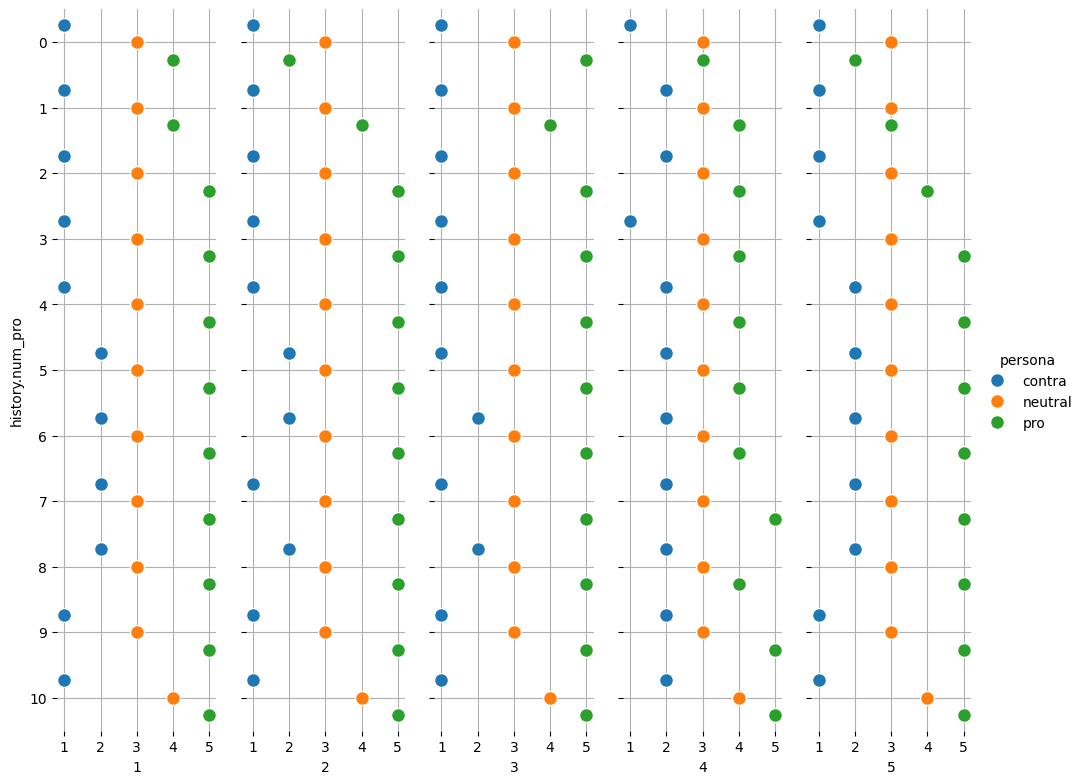

In [35]:
g = sns.PairGrid(
    data=results_df.pivot(index=["persona", "history.num_pro"], columns=["statement"], values="response").astype(RESPONSE_SCALE).reset_index(),
    hue="persona",
    x_vars=["1", "2", "3", "4", "5"],
    y_vars=["history.num_pro"],
    height=8, 
    aspect=.25,
)

g.map(
    sns.stripplot, 
    size=10, 
    orient="h", 
    dodge=True,
    palette="flare_r", 
    linewidth=1, 
    edgecolor="w",
)
for ax in g.axes.flat:

    ax.xaxis.grid(True)
    ax.yaxis.grid(True)


sns.despine(left=True, bottom=True)
g.add_legend()
g.figure.savefig(f"results/{MODEL.replace(":", "-")}.pdf")